# EGFP design campaign — scaffold vs design vs target peaks

Visualize, for each of the 4 EGFP→target pairs, where the **scaffold** and **target** sit in
`(excitation, emission)` space and where the **guided designs** land, as **predicted by the
surrogate** (ESM-2 `cnn-max-d1`, all-data).

- **scaffold (measured)** and **target (measured)** — the real FPBase `(ex, em)` peaks.
- **design (surrogate)** — the surrogate's predicted `(ex, em)` for each of the 6 designed sequences
  per pair (final iteration), with the per-trial trajectory (rounds 0→3) drawn faintly.

> **No oracle for this task.** The design predictions come from the same surrogate that guided the
> search, so they are *in-sample / optimistic*, not independent validation. The scaffold and target
> markers are measured values; only the design markers are model predictions.

Data source: `guided_design/designs/design_*.csv` (produced by `guided_design/design_campaign.py`).

In [1]:
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def load_designs(designs_dir):
    fs = sorted(glob.glob(str(Path(designs_dir) / "design_*.csv")))
    d = pd.concat([pd.read_csv(f) for f in fs], ignore_index=True)
    d["pair"] = d["scaffold_name"] + " \u2192 " + d["target_name"]
    return d


def best_per_trial(d):
    """One row per (pair, trial): the ITERATION ROUND (>=1) with the smallest surrogate peak_err.
    Round 0 is the untouched scaffold and is EXCLUDED, so a 'best design' is always an actual edited
    sequence (never the original scaffold), even if every design is worse than the scaffold."""
    dd = d[d["round"] >= 1]
    idx = dd.groupby(["pair", "trial"])["peak_err"].idxmin()
    return dd.loc[idx].reset_index(drop=True)


def pair_summary(d):
    """Per pair: scaffold error (round 0) and mean/best over each trial's BEST round."""
    bt = best_per_trial(d)
    out = []
    for p, g in d.groupby("pair"):
        b = bt.loc[bt["pair"] == p, "peak_err"]
        out.append(dict(pair=p, scaffold_err=g.loc[g["round"] == 0, "peak_err"].iloc[0],
                        mean_design=b.mean(), best_design=b.min()))
    return pd.DataFrame(out).sort_values("best_design").reset_index(drop=True)


# locate guided_design/designs whether the notebook runs from the campaign root or the repo root
_cands = [Path("guided-design/designs"), Path("guided_design/designs"),
          Path("design-campaign-EGFP/guided-design/designs"),
          Path("design-campaign-EGFP/guided_design/designs"),
          Path.cwd() / "guided-design" / "designs", Path.cwd() / "guided_design" / "designs"]
DESIGNS = next((c for c in _cands if c.exists()), None)
assert DESIGNS is not None, "could not find guided_design/designs; run this notebook from design-campaign-EGFP/"
FIGDIR = DESIGNS.parent.parent / "figures"; FIGDIR.mkdir(exist_ok=True)

df = load_designs(DESIGNS)
RMAX = int(df["round"].max())
pairs = df.groupby("pair")["scaffold_idx"].first().index.tolist()
summary = pair_summary(df)

# Gibbs is target-free (one design_<scaffold>.csv). Reconstruct a per-target view by pairing each
# gibbs design with every target's peaks (taken from df) and recomputing the surrogate distance, so
# the guided-vs-gibbs comparison cells below have a `dfg` aligned 1:1 with df's targets.
_gcands = [Path("gibbs-sampling/designs"), Path("design-campaign-EGFP/gibbs-sampling/designs"),
           Path.cwd() / "gibbs-sampling" / "designs"]
GIBBS = next((c for c in _gcands if c.exists()), None)
assert GIBBS is not None, "could not find gibbs-sampling/designs"
_gbase = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(GIBBS / "design_*.csv")))],
                   ignore_index=True)
_tg = df[["target_name", "target_idx", "target_ex", "target_em"]].drop_duplicates()
dfg = _gbase.merge(_tg, how="cross")
dfg["pair"] = dfg["scaffold_name"] + " \u2192 " + dfg["target_name"]
dfg["peak_err"] = 0.5 * ((dfg["pred_ex"] - dfg["target_ex"]).abs()
                         + (dfg["pred_em"] - dfg["target_em"]).abs())
RMAX_G = int(dfg["round"].max())
summary_g = pair_summary(dfg)

print(f"loaded {df['pair'].nunique()} pairs, {len(df)} rows | rounds 0..{RMAX} | trials {df.trial.nunique()}")
print(f"gibbs (target-free): {_gbase['designed_seq'].nunique()} unique designs \u00d7 "
      f"{dfg['target_name'].nunique()} targets | rounds 0..{RMAX_G}")
print(f"[each trial's best round] improved best over scaffold: "
      f"{(summary.best_design < summary.scaffold_err).sum()}/{len(summary)} | "
      f"best within 10 nm: {(summary.best_design < 10).sum()}/{len(summary)}")
summary.round(1)

loaded 2 pairs, 576 rows | rounds 0..3 | trials 96
gibbs (target-free): 289 unique designs × 2 targets | rounds 0..3
[each trial's best round] improved best over scaffold: 2/2 | best within 10 nm: 2/2


,pair,scaffold_err,mean_design,best_design
0,EGFP → EBFP,88.3,2.7,0.0
1,EGFP → mOrange,56.7,15.7,1.7


## Guided vs Gibbs — per-peak distance to target

Distance of **each individual design** from its target, with the **excitation** and **emission**
peaks separated: `|Δex| = |pred_ex − target_ex|` and `|Δem| = |pred_em − target_em|`
(surrogate-predicted). Each point is one design attempt taken at **its best round** (the round ≥ 1 that
minimizes surrogate peak error — the scaffold at round 0 is excluded, so every point is a real edit).
The black bar marks the median.
Both guided and Gibbs draw 6 attempts/pair here.

saved figures/campaign_peak_distance_strip.png

peak        method      n   median    mean     p90
Excitation  guided    144     14.8    13.9    29.4
Excitation  gibbs     192     67.4    68.3    86.9
Emission    guided    144      4.4     8.8    24.1
Emission    gibbs     192     52.5    52.5    65.1


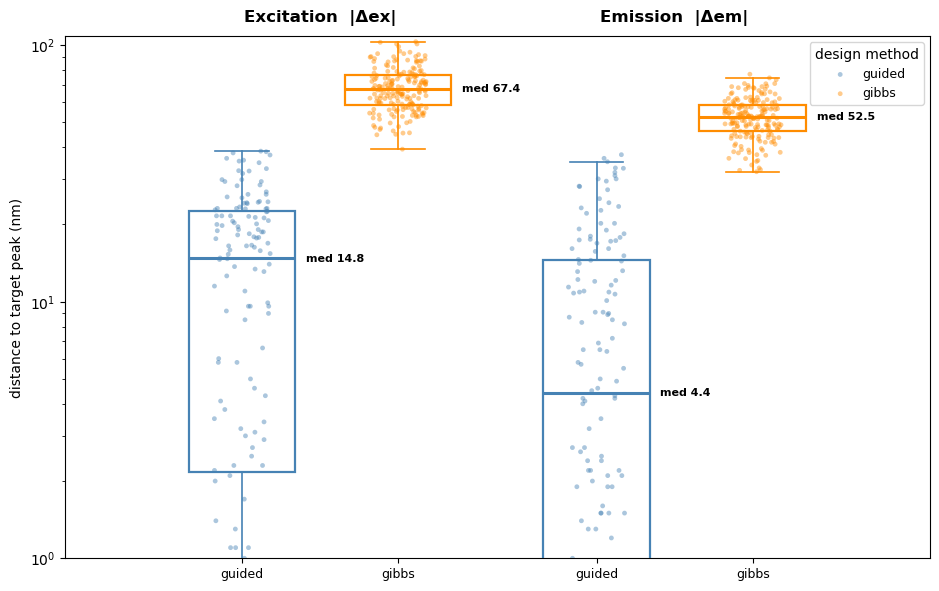

In [2]:
methods = [("guided", df, "steelblue"), ("gibbs", dfg, "darkorange")]
peaks = [("Excitation  |\u0394ex|", "pred_ex", "target_ex"),
         ("Emission  |\u0394em|", "pred_em", "target_em")]
rng = np.random.default_rng(0)

fig, ax = plt.subplots(figsize=(9.5, 6))
tick_x, tick_lab = [], []
stats = []
for pk_i, (pk_label, pcol, tcol) in enumerate(peaks):
    for m_i, (mname, d, color) in enumerate(methods):
        fin = best_per_trial(d)   # each trial's best round (min surrogate peak_err)
        dist = (fin[pcol] - fin[tcol]).abs().to_numpy()
        cx = pk_i + (-0.22 if m_i == 0 else 0.22)
        # boxplot with TRANSPARENT facecolor (edges/median in the method colour)
        ax.boxplot([dist], positions=[cx], widths=0.30, showfliers=False, patch_artist=True,
                   boxprops=dict(facecolor="none", edgecolor=color, linewidth=1.6),
                   medianprops=dict(color=color, linewidth=2.2),
                   whiskerprops=dict(color=color, linewidth=1.2),
                   capprops=dict(color=color, linewidth=1.2), zorder=3)
        # stripplot: jittered individual designs over the box
        x = cx + rng.uniform(-0.08, 0.08, size=len(dist))
        ax.scatter(x, dist, s=12, c=color, alpha=0.45, edgecolor="none",
                   label=mname if pk_i == 0 else None, zorder=4)
        med = float(np.median(dist))
        ax.text(cx + 0.18, med, f"med {med:.1f}", ha="left", va="center", fontsize=8,
                fontweight="bold", zorder=6)
        tick_x.append(cx); tick_lab.append(mname)
        stats.append((pk_label.split()[0], mname, len(dist), med,
                      float(np.mean(dist)), float(np.percentile(dist, 90))))

ax.set_xticks(tick_x); ax.set_xticklabels(tick_lab, fontsize=9)
for pk_i, (pk_label, _, _) in enumerate(peaks):
    ax.text(pk_i, 1.02, pk_label, ha="center", va="bottom", fontsize=12,
            fontweight="bold", transform=ax.get_xaxis_transform())
ax.axhline(0, color="0.6", lw=0.8)
ax.set_ylabel("distance to target peak (nm)")
ax.set_ylim(bottom=1)
ax.set_yscale("log")
ax.legend(title="design method", fontsize=9, loc="upper right", frameon=True)
ax.margins(x=0.08)
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_peak_distance_strip.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_peak_distance_strip.png\n")
print(f"{'peak':12}{'method':8}{'n':>5}{'median':>9}{'mean':>8}{'p90':>8}")
for pk, mn, n, md, me, p9 in stats:
    print(f"{pk:12}{mn:8}{n:>5}{md:>9.1f}{me:>8.1f}{p9:>8.1f}")
plt.show()

## Convergence — surrogate MAE vs iteration round

For each method, plot the surrogate MAE to target (`½(|Δex| + |Δem|)` = `peak_err`) against the
iteration round. At every round a single **unfilled boxplot** (`facecolor='none'`) summarizes the
distribution pooled across **all** shown designs; a **connected median** line and a **connected
minimum** line track the round-over-round trend. Every **design attempt** (one trial's trajectory) is
also overlaid faintly in its **pair's color** (round 0 is the shared scaffold starting point).

Tune `N_PAIRS_SHOW` / `N_TRIALS_SHOW` below to control which designs are pooled and overlaid.

saved figures/campaign_convergence_guided.png


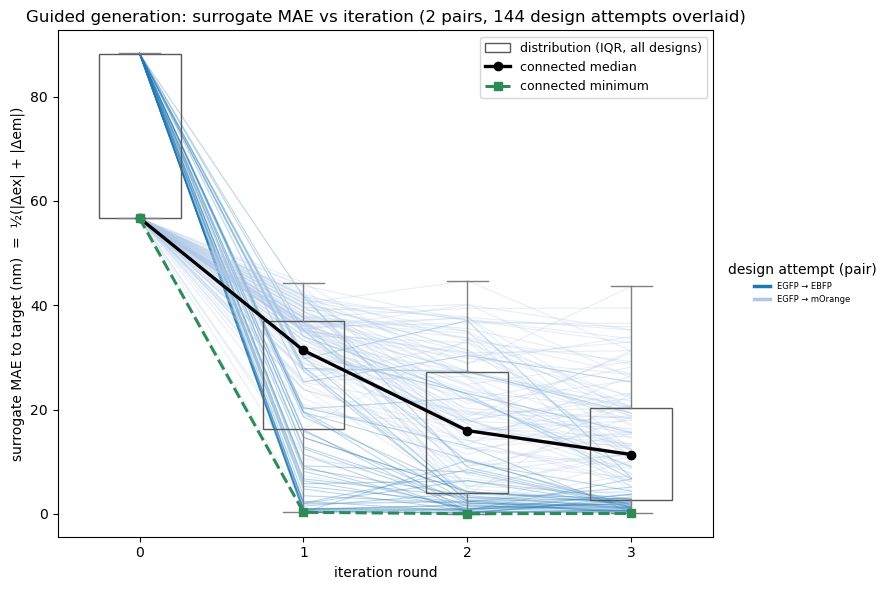

saved figures/campaign_convergence_gibbs.png


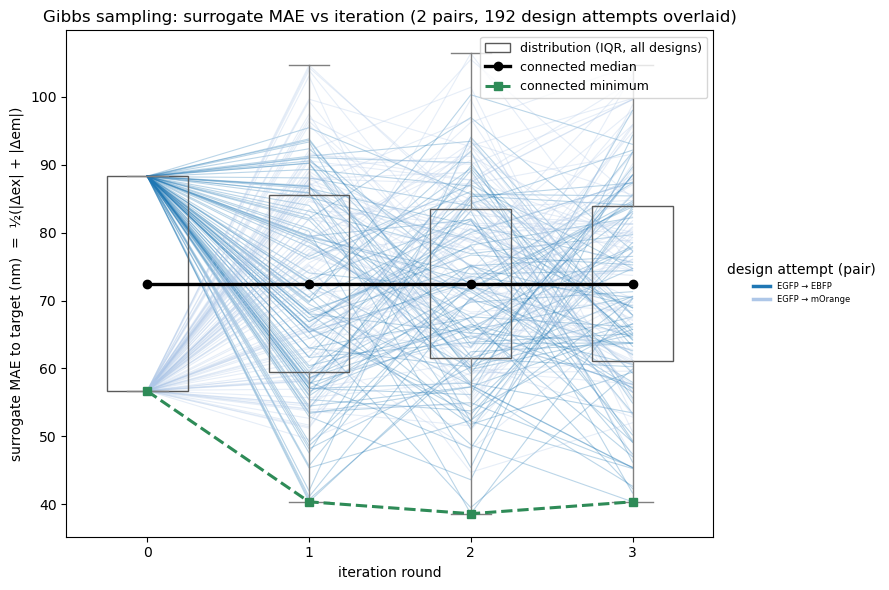

In [3]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

# ---- tune which designs go into the aggregate distribution ------------------------
N_PAIRS_SHOW = 2         # number of scaffold->target pairs pooled into the boxplots
N_TRIALS_SHOW = None     # trials per pair pooled; None = all trials
# ----------------------------------------------------------------------------------


def plot_convergence(d, method_name, fname, n_pairs=N_PAIRS_SHOW, n_trials=N_TRIALS_SHOW):
    rmax = int(d["round"].max())
    rounds = list(range(rmax + 1))
    ps = d.groupby("pair")["scaffold_idx"].first().index.tolist()[:n_pairs]

    cmap = plt.get_cmap("tab20")
    pair_color = {p: cmap(i % 20) for i, p in enumerate(ps)}

    sub = d[d["pair"].isin(ps)].copy()
    if n_trials is not None:
        sub = sub[sub["trial"] < n_trials]

    # one aggregate distribution per round, pooled across ALL shown designs
    box_data = [sub.loc[sub["round"] == r, "peak_err"].to_numpy() for r in rounds]

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.boxplot(box_data, positions=rounds, widths=0.5, showfliers=False, patch_artist=True,
               zorder=4, boxprops=dict(facecolor="none", edgecolor="0.35"),
               medianprops=dict(color="none"), whiskerprops=dict(color="0.5"),
               capprops=dict(color="0.5"))

    # overlay each individual design attempt (one trial's trajectory), colored by pair
    n_shown = 0
    for p in ps:
        for tr, gt in sub[sub["pair"] == p].groupby("trial"):
            gt = gt.sort_values("round")
            ax.plot(gt["round"], gt["peak_err"], "-", color=pair_color[p],
                    alpha=0.3, lw=0.8, zorder=2)
            n_shown += 1

    # connected median and connected minimum across rounds (over all pooled designs)
    meds = [float(np.median(b)) for b in box_data]
    mins = [float(np.min(b)) for b in box_data]
    ax.plot(rounds, meds, "-o", color="black", lw=2.4, ms=6, zorder=6)
    ax.plot(rounds, mins, "--s", color="seagreen", lw=2.2, ms=6, zorder=6)

    ax.set_xticks(rounds); ax.set_xlim(-0.5, rmax + 0.5)
    ax.set_xlabel("iteration round")
    ax.set_ylabel("surrogate MAE to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
    ax.set_title(f"{method_name}: surrogate MAE vs iteration "
                 f"({len(ps)} pairs, {n_shown} design attempts overlaid)")

    style_leg = ax.legend([Patch(facecolor="none", edgecolor="0.35"),
                           Line2D([0], [0], color="black", lw=2.4, marker="o"),
                           Line2D([0], [0], color="seagreen", lw=2.2, ls="--", marker="s")],
                          ["distribution (IQR, all designs)", "connected median", "connected minimum"],
                          loc="upper right", fontsize=9, frameon=True)
    ax.add_artist(style_leg)
    ax.legend([Line2D([0], [0], color=pair_color[p], lw=2.5) for p in ps], ps,
              fontsize=6, ncol=1, loc="center left", bbox_to_anchor=(1.01, 0.5),
              frameon=False, title="design attempt (pair)")
    fig.tight_layout()
    fig.savefig(FIGDIR / fname, dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / fname)
    plt.show()


plot_convergence(df, "Guided generation", "campaign_convergence_guided.png")
plot_convergence(dfg, "Gibbs sampling", "campaign_convergence_gibbs.png")

## Are the designs in-distribution for the GFP-family DMS brightness models?

The DMS brightness models were trained on ESM-2 650M embeddings of large deep-mutational-scanning
libraries built on **four GFP scaffolds**: **avGFP** (Sarkisyan) plus the three orthologs
**amacGFP**, **cgreGFP**, and **ppluGFP**. To judge whether our EGFP designs are
**in-distribution (ID)** or **out-of-distribution (OOD)**, we compare embeddings directly:

- **DMS clouds** — **max-pooled** ESM-2 embeddings of **1,000 randomly sampled sequences per
  scaffold** (4,000 total), read from the cached per-residue embeddings
  (`avgfp_dms` → `esm_residue_fp16.npy`; `amacGFP`/`cgreGFP`/`ppluGFP` → `ortho_gfp_dms_esm_residue_fp16.npy`).
  Max-pool matches the CNN(1)-max model's own pooling, so this is the representation closest to what
  the models actually key on.
- **Designs** — the unique designed sequences (guided + gibbs, all iterations), reframed to the DMS
  window (`seq[3:238]`) and **max-pooled** the same way, so the comparison is apples-to-apples.

We (1) project everything onto PCA axes fit on the **combined 4-scaffold cloud** so you can see which
scaffold family each design lands in, and (2) quantify OOD-ness with the distance from each design to
its nearest DMS neighbor (standardized embedding space) versus the DMS's own internal
nearest-neighbor distances. Designs sitting outside the clouds / with large NN distances are
extrapolations the brightness models cannot be trusted on.

In [4]:
# Build max-pooled ESM-2 embeddings for 1k sequences per GFP scaffold + the (reframed) unique designs.
import sys, torch
from collections import Counter
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors

# locate repo root (folder holding the GFP DMS cache) whether cwd is the campaign dir or the repo
HERE = Path.cwd()
REPO = next((b for b in [HERE, *HERE.parents]
             if any((b / d / "DMS_data").exists() for d in ("avGFP_DMS", "GFP_DMS"))), HERE.parent)
DMSD = next(REPO / d / "DMS_data" for d in ("avGFP_DMS", "GFP_DMS")
            if (REPO / d / "DMS_data").exists())
sys.path.insert(0, str(REPO / "esm2_design"))
import peak_models as pm
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("repo:", REPO, "| DMS:", DMSD.name, "| device:", dev)

# ---- DMS clouds: MAX-pool 1,000 random seqs from EACH of the 4 GFP scaffolds (cache to disk) ----
# avGFP lives in its own cache; amacGFP/cgreGFP/ppluGFP share the "ortho" cache. Each cache row is
# aligned 1:1 with its CSV, so we sample CSV row-indices and read those rows from the .npy.
N_PER = 10000
SCAFFOLDS = ["avGFP", "amacGFP", "cgreGFP", "ppluGFP"]
SRC = {  # scaffold -> (sequences csv, residue-embedding .npy, residue-length .npy, brightness col)
    "avGFP":   ("avgfp_dms_sequences.csv",     "esm_residue_fp16.npy",            "esm_residue_len.npy",            "logMedianBrightness"),
    "amacGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "cgreGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
    "ppluGFP": ("ortho_gfp_dms_sequences.csv", "ortho_gfp_dms_esm_residue_fp16.npy", "ortho_gfp_dms_esm_residue_len.npy", "logBrightness"),
}
MP_CACHE = DMSD / f"esm_maxpool_4scaffold_{N_PER//1000}k.npz"

def _maxpool_rows(Hpath, Lpath, rows):
    H = np.load(Hpath, mmap_mode="r"); Ls = np.load(Lpath).astype(int)
    out = np.zeros((len(rows), H.shape[2]), np.float32)
    for t, i in enumerate(rows):
        n = int(Ls[i]); r = np.asarray(H[i]).astype(np.float32)
        out[t] = r[:n].max(0) if n else 0.0
    return out

if MP_CACHE.exists():
    _z = np.load(MP_CACHE, allow_pickle=True)
    mp, scaf_lab, y_dms = _z["mp"], _z["scaf"].astype(str), _z["y"]
    print(f"loaded cached 4-scaffold max-pool {mp.shape}")
else:
    rng0 = np.random.default_rng(0)
    parts, labs, ys = [], [], []
    for s in SCAFFOLDS:
        csv, emb, lenf, ycol = SRC[s]
        d = pd.read_csv(DMSD / csv)
        idx = d.index[d["scaffold"] == s].to_numpy() if "scaffold" in d.columns else d.index.to_numpy()
        take = np.sort(rng0.choice(idx, size=min(N_PER, len(idx)), replace=False))
        parts.append(_maxpool_rows(DMSD / emb, DMSD / lenf, take))
        labs.append(np.full(len(take), s)); ys.append(d[ycol].to_numpy()[take])
        print(f"  {s}: max-pooled {len(take)} / {len(idx)} available")
    mp = np.concatenate(parts); scaf_lab = np.concatenate(labs); y_dms = np.concatenate(ys)
    np.savez(MP_CACHE, mp=mp, scaf=scaf_lab, y=y_dms)
    print(f"cached 4-scaffold max-pool {mp.shape} -> {MP_CACHE.name}")

# per-scaffold consensus of the avGFP DMS = avGFP parent (235 aa) reference point
_dms_av = pd.read_csv(DMSD / "avgfp_dms_sequences.csv")
_arr = np.array([list(s) for s in _dms_av["mutatedSequence"].values])
PARENT235 = "".join(Counter(_arr[:, j]).most_common(1)[0][0] for j in range(_arr.shape[1]))

# ---- Designs: unique sequences (guided + gibbs, iterations >=1), reframed to the DMS window ----
alld = pd.concat([df.assign(_method="guided"), dfg.assign(_method="gibbs")], ignore_index=True)
alld = alld[alld["round"] >= 1]
uniq = alld.drop_duplicates("designed_seq").copy()
egfp = df["scaffold_seq"].iloc[0]
egfp235 = egfp[3:238]
uniq["seq235"] = uniq["designed_seq"].str[3:238]
uniq["nmut"] = uniq["seq235"].apply(lambda s: sum(a != b for a, b in zip(s, egfp235)))
print(f"unique designs: {len(uniq)} | mutation load vs EGFP: {uniq['nmut'].min()}-{uniq['nmut'].max()}")

@torch.no_grad()
def max_embed(seqs, bs=64):
    """Masked max-pool of ESM-2 650M per-residue embeddings -> (n, 1280) (matches CNN(1)-max)."""
    out = []
    for i in range(0, len(seqs), bs):
        Hh, mm = pm.resid_embed(list(seqs[i:i + bs]), dev)
        out.append(pm.masked_pool(Hh, mm, "max").float().cpu().numpy())
    return np.concatenate(out)

dmp = max_embed(uniq["seq235"].tolist())             # designs
ref = max_embed([egfp235, PARENT235])                # EGFP scaffold + avGFP parent
egfp_mp, parent_mp = ref[0:1], ref[1:2]
print("design embeddings:", dmp.shape)

# ---- PCA fit on the COMBINED 4-scaffold cloud; project everything ----
mu, sd = mp.mean(0), mp.std(0) + 1e-6
Z = (mp - mu) / sd
pca = PCA(n_components=2, random_state=0).fit(Z)
P_dms = pca.transform(Z)
P_des = pca.transform((dmp - mu) / sd)
P_egfp = pca.transform((egfp_mp - mu) / sd)
P_par = pca.transform((parent_mp - mu) / sd)

# ---- all 758 curated "true" FPs (dataset pipeline): max-pool the precomputed ESM-2 residue
#      embeddings (aligned 1:1 with peaks_assignments.csv) and project onto the SAME PCA ----
CUR = REPO / "dataset_pipeline" / "data" / "peak" / "curated"
_fp_assign = pd.read_csv(CUR / "peaks_assignments.csv")
fp_mp = _maxpool_rows(CUR / "esm_residue_fp16.npy", CUR / "esm_residue_len.npy",
                      np.arange(len(_fp_assign)))
P_fp = pca.transform((fp_mp - mu) / sd)
print(f"curated true FPs: {P_fp.shape[0]} ESM-2 max-pool embeddings projected onto the PCA")

# ---- KDE density contours (replaces dense per-scaffold scatter when there are too many points) ----
from scipy.stats import gaussian_kde

def kde_contours(ax, P2, color, label=None, n_levels=9, grid=160, thresh=0.08, pad=0.25,
                 zorder=1):
    """Draw a filled outer blob + several light density contour lines for a 2D point cloud.
    The grid is padded beyond the data range (pad = fraction of each axis span) so the outer
    contours CLOSE instead of being clipped at the point bounding box."""
    x, y = P2[:, 0], P2[:, 1]
    k = gaussian_kde(np.vstack([x, y]))
    xpad = (x.max() - x.min()) * pad + 1e-6; ypad = (y.max() - y.min()) * pad + 1e-6
    xs = np.linspace(x.min() - xpad, x.max() + xpad, grid)
    ys = np.linspace(y.min() - ypad, y.max() + ypad, grid)
    XX, YY = np.meshgrid(xs, ys)
    ZZ = k(np.vstack([XX.ravel(), YY.ravel()])).reshape(XX.shape)
    zmax = ZZ.max()
    ax.contourf(XX, YY, ZZ, levels=[zmax * thresh, zmax], colors=[color], alpha=0.08, zorder=zorder)
    ax.contour(XX, YY, ZZ, levels=np.linspace(zmax * thresh, zmax, n_levels), colors=color,
               linewidths=0.6, alpha=0.45, zorder=zorder)
    if label:
        ax.plot([], [], color=color, lw=3, alpha=0.55, label=label)   # proxy handle for the legend

# ---- OOD metric: NN distance (standardized space) design->DMS vs DMS internal ----
rng = np.random.default_rng(0)
Zd = (dmp - mu) / sd
nn = NearestNeighbors(n_neighbors=1).fit(Z)          # reference = the full 4k DMS sample
d_des, _ = nn.kneighbors(Zd)                          # each design -> nearest DMS (any scaffold)
nn2 = NearestNeighbors(n_neighbors=2).fit(Z)
d_dms, _ = nn2.kneighbors(Z)                          # DMS internal (2nd nbr excludes self)
d_des, d_dms = d_des.ravel(), d_dms[:, 1]
p99 = np.percentile(d_dms, 99)
frac_ood = float((d_des > p99).mean())

# which scaffold family is each design nearest to?
near_by_scaf = {}
for s in SCAFFOLDS:
    m = scaf_lab == s
    near_by_scaf[s] = NearestNeighbors(n_neighbors=1).fit(Z[m]).kneighbors(Zd)[0].ravel()
nearest_scaf = np.array(SCAFFOLDS)[np.argmin(np.column_stack([near_by_scaf[s] for s in SCAFFOLDS]), 1)]

print(f"\nNN-distance (standardized embedding):")
print(f"  DMS internal   median {np.median(d_dms):.2f}   99th pct {p99:.2f}")
print(f"  designs->DMS   median {np.median(d_des):.2f}   range {d_des.min():.2f}-{d_des.max():.2f}")
print(f"  designs beyond DMS 99th-pct NN distance: {frac_ood:.1%}")
print("  nearest-scaffold family for designs:",
      {s: int((nearest_scaf == s).sum()) for s in SCAFFOLDS})

repo: /home/ubuntu/spectrum-to-fp-design | DMS: DMS_data | device: cuda
loaded cached 4-scaffold max-pool (40000, 1280)


unique designs: 720 | mutation load vs EGFP: 13-25


design embeddings: (720, 1280)


curated true FPs: 758 ESM-2 max-pool embeddings projected onto the PCA



NN-distance (standardized embedding):
  DMS internal   median 13.06   99th pct 30.21
  designs->DMS   median 41.07   range 27.93-64.33
  designs beyond DMS 99th-pct NN distance: 99.2%
  nearest-scaffold family for designs: {'avGFP': 720, 'amacGFP': 0, 'cgreGFP': 0, 'ppluGFP': 0}


saved figures/campaign_dms_ood_4scaffold.png


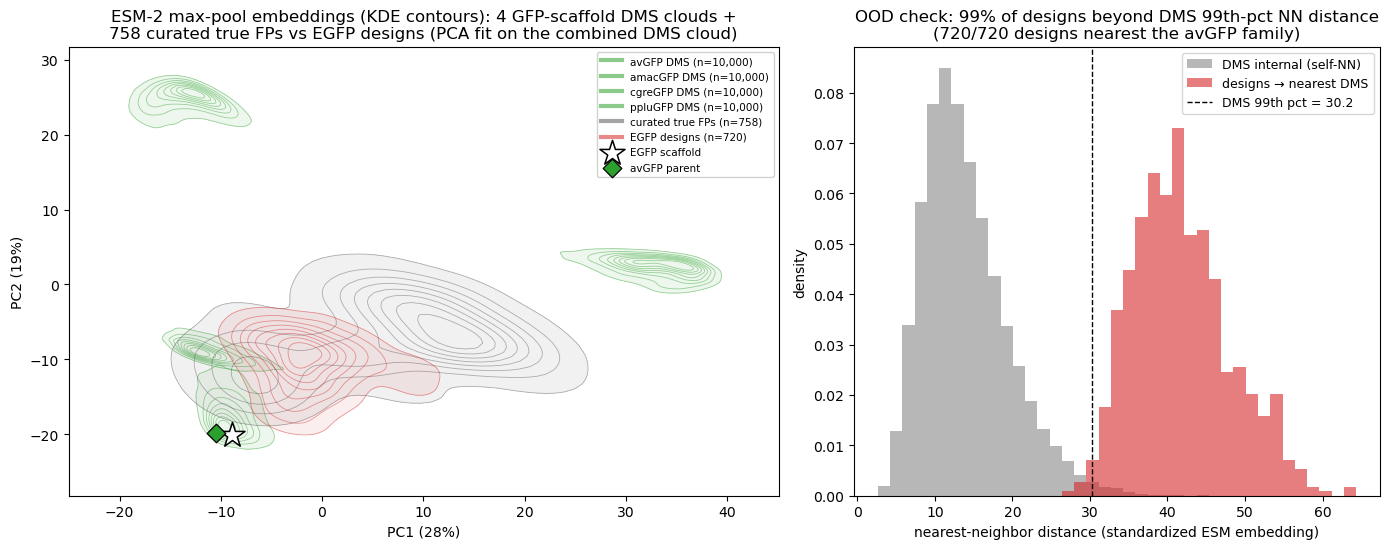

In [5]:
# Left: PCA of the 4 GFP-scaffold DMS clouds vs designs. Right: OOD NN-distance histograms.
fig, (axP, axH) = plt.subplots(1, 2, figsize=(14, 5.6), gridspec_kw={"width_ratios": [1.35, 1]})

# --- PCA: KDE density contours per DMS scaffold (1k each) + 758 true FPs + designs by mutation load ---
SCAF_COLORS = {s: "#2ca02c" for s in ("avGFP", "amacGFP", "cgreGFP", "ppluGFP")}  # all GFP DMS = green
for s in SCAFFOLDS:
    m = scaf_lab == s
    kde_contours(axP, P_dms[m], SCAF_COLORS[s], label=f"{s} DMS (n={int(m.sum()):,})")
kde_contours(axP, P_fp, "0.35", label=f"curated true FPs (n={P_fp.shape[0]})", zorder=2)
kde_contours(axP, P_des, "#d62728", label=f"EGFP designs (n={P_des.shape[0]})", zorder=3)
axP.scatter(*P_egfp[0], marker="*", s=360, c="w", edgecolor="k", linewidth=1.1,
            zorder=4, label="EGFP scaffold")
axP.scatter(*P_par[0], marker="D", s=90, c="#2ca02c", edgecolor="k", linewidth=0.9,
            zorder=4, label="avGFP parent")
axP.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
axP.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
axP.set_title("ESM-2 max-pool embeddings (KDE contours): 4 GFP-scaffold DMS clouds +\n"
              "758 curated true FPs vs EGFP designs (PCA fit on the combined DMS cloud)")
_focus = np.vstack([P_dms, P_des, P_egfp, P_par])     # zoom to the DMS+design region (true FPs may clip)
_mx = (_focus[:, 0].max() - _focus[:, 0].min()) * 0.08
_my = (_focus[:, 1].max() - _focus[:, 1].min()) * 0.08
axP.set_xlim(_focus[:, 0].min() - _mx, _focus[:, 0].max() + _mx)
axP.set_ylim(_focus[:, 1].min() - _my, _focus[:, 1].max() + _my)
axP.legend(loc="best", fontsize=7.5, framealpha=0.9)

# --- NN-distance histograms (OOD): DMS internal vs designs, per-scaffold nearest overlaid ---
lo = min(d_dms.min(), d_des.min()); hi = max(d_dms.max(), d_des.max())
bins = np.linspace(lo, hi, 40)
axH.hist(d_dms, bins=bins, density=True, color="0.6", alpha=0.7, label="DMS internal (self-NN)")
axH.hist(d_des, bins=bins, density=True, color="#d62728", alpha=0.6, label="designs \u2192 nearest DMS")
axH.axvline(p99, ls="--", color="k", lw=1, label=f"DMS 99th pct = {p99:.1f}")
axH.set_xlabel("nearest-neighbor distance (standardized ESM embedding)")
axH.set_ylabel("density")
_topscaf, _topn = Counter(nearest_scaf).most_common(1)[0]
axH.set_title(f"OOD check: {frac_ood:.0%} of designs beyond DMS 99th-pct NN distance\n"
              f"({_topn}/{len(d_des)} designs nearest the {_topscaf} family)")
axH.legend(fontsize=9)
plt.tight_layout()
fig.savefig(FIGDIR / "campaign_dms_ood_4scaffold.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_dms_ood_4scaffold.png")
plt.show()

## In-distribution, per strategy — design contour + top-10 shortlist

One panel **per strategy** (5 total), each dropping that strategy onto the *same* 4-scaffold DMS
embedding space (same fitted PCA, standardization, and nearest-neighbor reference). Each panel shows
the four **GFP-DMS clouds** (green KDE contours) as shared background, the strategy's **full design
pool** as a KDE contour, and its **top-10 shortlist** designs as a scatter — all coloured by target
(**mOrange = orange**, **EBFP = blue**). A sixth panel gives the **OOD metric**: the nearest-neighbor
distance distribution for each strategy (distinct colours) vs the DMS internal self-NN, with the 99th
-pct threshold. The idea: strategies whose designs (and especially their shortlisted top-10) sit
inside the green clouds are in-distribution, so the brightness classifier's calls on them are more
trustworthy; strategies that extrapolate far out (high % OOD) are riskier.

gibbs                      (mOrange) pool n=288 | top-10 located 10 | NN-dist med 42.7 | OOD(>30.2) 100%


spectra guide              (mOrange) pool n=288 | top-10 located 10 | NN-dist med 40.0 | OOD(>30.2) 98%


constrained spectra guide  (mOrange) pool n=288 | top-10 located 10 | NN-dist med 34.6 | OOD(>30.2) 85%


DMS guide - bright         (mOrange) pool n=287 | top-10 located 10 | NN-dist med 28.9 | OOD(>30.2) 32%


DMS guide - bright         (EBFP) pool n=284 | top-10 located 10 | NN-dist med 29.3 | OOD(>30.2) 38%


saved figures/campaign_ood_per_strategy.png


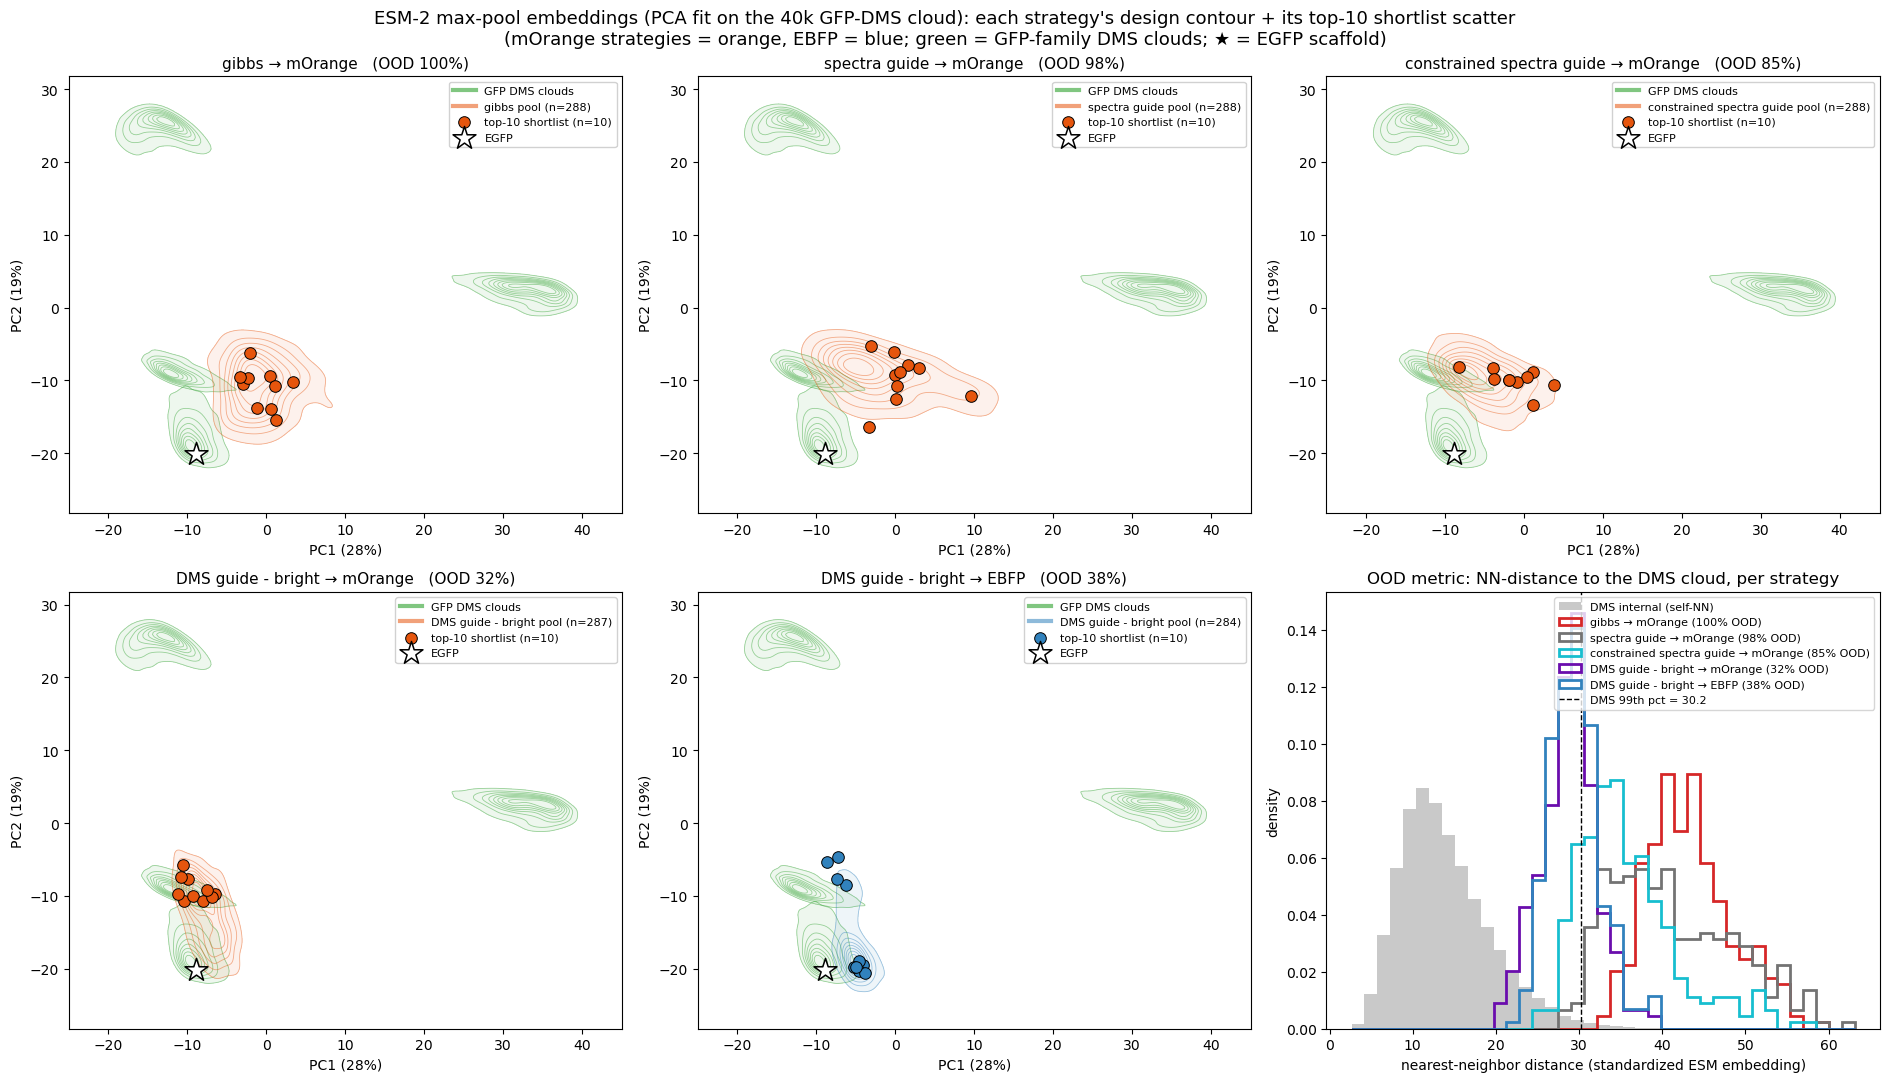

In [6]:
# ---- Per-strategy in-distribution panels (6 plots in one 2x3 figure):
#      panels 1-5 = one strategy each -> the 4 GFP-DMS clouds (green KDE) as shared background + that
#      strategy's FULL design pool as a KDE contour + its TOP-10 shortlist designs as a scatter, all
#      coloured by TARGET (mOrange = orange, EBFP = blue). panel 6 = the OOD metric: nearest-neighbour
#      distance distribution for EACH strategy (distinct colours so the 5 are distinguishable) vs the
#      DMS internal self-NN. Reuses P_dms, P_fp, P_egfp, scaf_lab, SCAFFOLDS, SCAF_COLORS, kde_contours,
#      mu, sd, pca, nn, p99, d_dms, max_embed, GIBBS, DESIGNS, FIGDIR from the cells above.
CAMP = DESIGNS.parent.parent
SL = CAMP / "shortlists"
ORANGE, BLUE = "#e6550d", "#3182bd"
B60 = CAMP / "brightness-guided" / "guided_design" / "designs_lam-bright60_lam-edit10"
CONS = CAMP / "guided-design-constraint" / "designs_lam-edit10"
CASES = [   # (label, target, full-pool csv, shortlist xlsx, target-colour, hist-colour)
    ("gibbs",                     "mOrange", GIBBS / "design_EGFP.csv",          "shortlist_mOrange_gibbs.xlsx",                      ORANGE, "#d62728"),
    ("spectra guide",             "mOrange", DESIGNS / "design_EGFP-mOrange.csv", "shortlist_mOrange_spectra-guide.xlsx",             ORANGE, "0.45"),
    ("constrained spectra guide", "mOrange", CONS / "design_EGFP-mOrange.csv",    "shortlist_mOrange_constrained-spectra-guide.xlsx", ORANGE, "#17becf"),
    ("DMS guide - bright",        "mOrange", B60 / "design_EGFP-mOrange.csv",     "shortlist_mOrange_DMS-guide.xlsx",                 ORANGE, "#6a0dad"),
    ("DMS guide - bright",        "EBFP",    B60 / "design_EGFP-EBFP.csv",        "shortlist_EBFP_DMS-guide.xlsx",                    BLUE,   "#3182bd"),
]

def _pool_embed(csv):
    d = pd.read_csv(csv); d = d[d["round"] >= 1].drop_duplicates("designed_seq").copy()
    Zx = (max_embed(d["designed_seq"].str[3:238].tolist()) - mu) / sd
    return d, pca.transform(Zx), nn.kneighbors(Zx)[0].ravel()

cases = []
for label, tgt, csv, slf, tcol, hcol in CASES:
    d, P, dist = _pool_embed(csv)
    sl = pd.read_excel(SL / slf); sl = sl[sl["role"] == "design"]
    top = d["designed_seq"].isin(set(sl["aa_sequence"])).to_numpy()   # locate the shortlist within the pool
    cases.append(dict(label=label, tgt=tgt, tcol=tcol, hcol=hcol, d=d, P=P, dist=dist,
                      Ptop=P[top], ood=float((dist > p99).mean())))
    print(f"{label:26} ({tgt}) pool n={len(d):3d} | top-10 located {int(top.sum())} | "
          f"NN-dist med {np.median(dist):.1f} | OOD(>{p99:.1f}) {(dist > p99).mean():.0%}")

# zoom shared across the 5 PCA panels (DMS + all design pools + EGFP)
_focus = np.vstack([P_dms, P_egfp] + [c["P"] for c in cases])
xmn, xmx = _focus[:, 0].min(), _focus[:, 0].max(); ymn, ymx = _focus[:, 1].min(), _focus[:, 1].max()
xpad = (xmx - xmn) * 0.08; ypad = (ymx - ymn) * 0.08

fig, axes = plt.subplots(2, 3, figsize=(19, 11)); axes = axes.ravel()
for ax, c in zip(axes[:5], cases):
    for s in SCAFFOLDS:                                       # shared green DMS background
        kde_contours(ax, P_dms[scaf_lab == s], SCAF_COLORS[s])
    ax.plot([], [], color="#2ca02c", lw=3, alpha=0.6, label="GFP DMS clouds")
    kde_contours(ax, c["P"], c["tcol"], label=f"{c['label']} pool (n={len(c['d'])})", zorder=3)
    ax.scatter(c["Ptop"][:, 0], c["Ptop"][:, 1], s=70, c=c["tcol"], edgecolor="k", linewidth=0.7,
               zorder=5, label=f"top-10 shortlist (n={len(c['Ptop'])})")
    ax.scatter(*P_egfp[0], marker="*", s=300, c="w", edgecolor="k", linewidth=1.1, zorder=6, label="EGFP")
    ax.set_title(f"{c['label']} \u2192 {c['tgt']}   (OOD {c['ood']:.0%})", fontsize=11)
    ax.set_xlim(xmn - xpad, xmx + xpad); ax.set_ylim(ymn - ypad, ymx + ypad)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}%)")
    ax.legend(fontsize=8, loc="best", framealpha=0.9)

# panel 6: NN-distance distribution for EACH strategy (distinct colours) vs DMS internal
axH = axes[5]
bins = np.linspace(min(d_dms.min(), *[c["dist"].min() for c in cases]),
                   max(d_dms.max(), *[c["dist"].max() for c in cases]), 40)
axH.hist(d_dms, bins=bins, density=True, color="0.7", alpha=0.7, label="DMS internal (self-NN)")
for c in cases:
    axH.hist(c["dist"], bins=bins, density=True, histtype="step", lw=2.0, color=c["hcol"],
             label=f"{c['label']} \u2192 {c['tgt']} ({c['ood']:.0%} OOD)")
axH.axvline(p99, ls="--", color="k", lw=1, label=f"DMS 99th pct = {p99:.1f}")
axH.set_xlabel("nearest-neighbor distance (standardized ESM embedding)")
axH.set_ylabel("density"); axH.set_title("OOD metric: NN-distance to the DMS cloud, per strategy")
axH.legend(fontsize=8)

fig.suptitle("ESM-2 max-pool embeddings (PCA fit on the 40k GFP-DMS cloud): each strategy's design "
             "contour + its top-10 shortlist scatter\n(mOrange strategies = orange, EBFP = blue; "
             "green = GFP-family DMS clouds; \u2605 = EGFP scaffold)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGDIR / "campaign_ood_per_strategy.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_ood_per_strategy.png")
plt.show()

## Top-10 shortlisted designs per strategy vs target — EBFP

Bar view of the finalized **shortlist** for **EBFP** (large blue shift, em 440 vs the scaffold's
507 nm). This cell no longer re-selects designs — it **loads `shortlists/shortlist_EBFP_*.xlsx`**
(built by `make_shortlist_case.py`) so the figure matches the wet-lab hand-off exactly. Only the
**DMS guide - bright** shortlist was generated for EBFP (top-10 designs that are both
**in-distribution** and **predicted bright**). Two barplots (excitation, emission): each bar = mean ±
sd of the shortlisted designs, individual designs overlaid as points, a green bar for the measured
**EGFP scaffold**, and a dashed line at the **EBFP target**.

=== EBFP: loaded shortlists/ | scaffold (488, 507) | target (380, 440) ===
  DMS guide - bright         n=10 | ex 404.2±8.3 | em 464.6±5.9 | best err 7.9 nm | ID 10/10 | bright 10/10
saved figures/campaign_top10_bars_EBFP.png


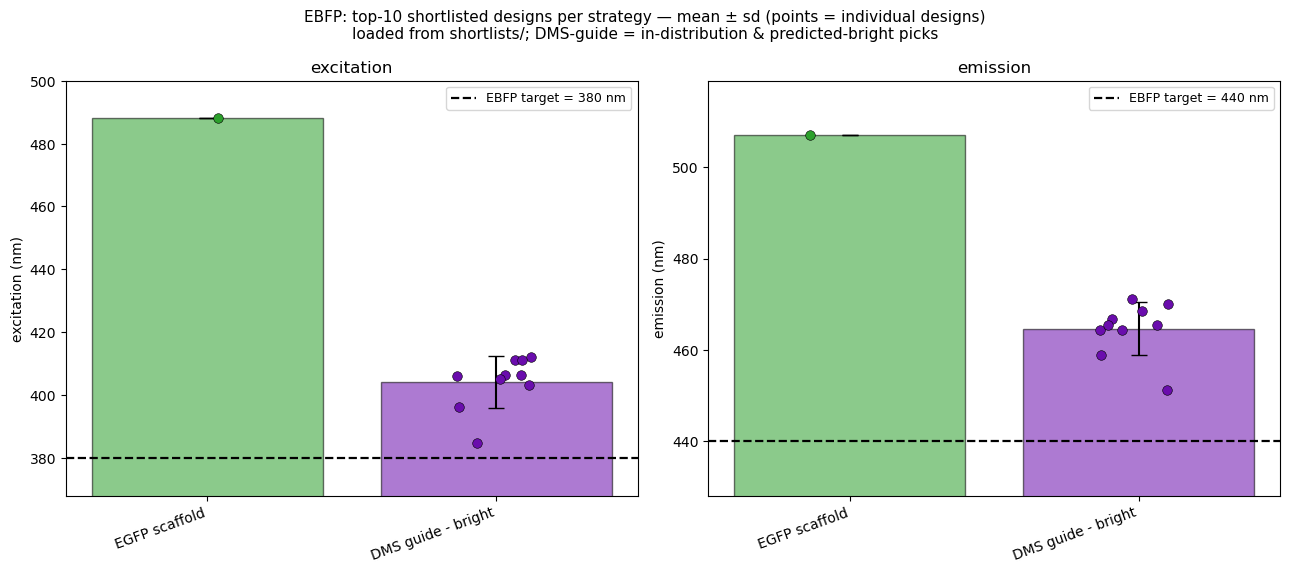

In [7]:
# --- Consolidated top-10 bar view, shared by EBFP and mOrange. Instead of re-selecting designs here,
#     this LOADS the finalized per-strategy shortlists in shortlists/*.xlsx (built by
#     make_shortlist_case.py) and plots exactly those picks, so the figure and the wet-lab hand-off
#     never drift. Each shortlist already carries the EGFP + target references (true ex/em) and the
#     top-10 diverse designs (DMS-guide = in-distribution & predicted-bright; the other strategies
#     unfiltered), with per-design is_id / is_bright flags. Bars L->R: EGFP scaffold (green) + one bar
#     per strategy present for that target. Reuses DESIGNS, FIGDIR, REPO, pm, dev, torch from above.
CAMP = DESIGNS.parent.parent
SL = CAMP / "shortlists"
SHORTLISTS = {   # target -> [(alias, shortlist file, colour), ...]  (only the files we generated)
    "mOrange": [
        ("gibbs",                     "shortlist_mOrange_gibbs.xlsx",                      "#d62728"),
        ("spectra guide",             "shortlist_mOrange_spectra-guide.xlsx",             "0.45"),
        ("constrained spectra guide", "shortlist_mOrange_constrained-spectra-guide.xlsx", "#17becf"),
        ("DMS guide - bright",        "shortlist_mOrange_DMS-guide.xlsx",                 "#6a0dad"),
    ],
    "EBFP": [
        ("DMS guide - bright",        "shortlist_EBFP_DMS-guide.xlsx",                    "#6a0dad"),
    ],
}

# ---- brightness oracle (cnn-max-d2, val AUROC 0.98): kept here because the "strategy comparison"
#      cell below re-scores gibbs/spectra designs (no pred_bright column) with this SAME checkpoint. ----
BRIGHT_CKPT = REPO / "fpdesign" / "models" / "brightness_cnn-max-d2_40k.pt"
_BNET = {}
def _bnet():
    if "n" not in _BNET:
        _bb, _bm = pm.load_model(str(BRIGHT_CKPT), dev, out=1)
        _BNET["n"] = pm.wrap(_bb, _bm.get("mean", 0.0) or 0.0, _bm.get("std", 1.0) or 1.0, dev)
    return _BNET["n"]

@torch.no_grad()
def _score_bright(full_seqs, bs=32):
    net, out = _bnet(), []
    for i in range(0, len(full_seqs), bs):
        H, m = pm.resid_embed(list(full_seqs[i:i + bs]), dev)
        out.append(net(H, m).float().cpu().numpy().ravel())
    return np.concatenate(out) if out else np.array([])

def _load_shortlist(fname):
    d = pd.read_excel(SL / fname)
    refs = d[d["role"] == "reference"].set_index("name")
    des = d[d["role"] == "design"].copy()
    return refs, des

def plot_groups(target):
    specs = SHORTLISTS[target]
    refs, _ = _load_shortlist(specs[0][1])                       # all shortlists share EGFP + target refs
    sex, sem = float(refs.loc["EGFP", "true_ex_nm"]), float(refs.loc["EGFP", "true_em_nm"])
    tex, tem = float(refs.loc[target, "true_ex_nm"]), float(refs.loc[target, "true_em_nm"])
    labels = ["EGFP scaffold"] + [a for a, _, _ in specs]
    colors = ["#2ca02c"] + [c for _, _, c in specs]             # green leftmost bar = EGFP scaffold
    ex_data, em_data = [np.array([sex])], [np.array([sem])]
    print(f"=== {target}: loaded shortlists/ | scaffold ({sex:.0f}, {sem:.0f}) | target ({tex:.0f}, {tem:.0f}) ===")
    for alias, fname, _c in specs:
        _, des = _load_shortlist(fname)
        ex = des["pred_ex_nm"].to_numpy(float); em = des["pred_em_nm"].to_numpy(float)
        ex_data.append(ex); em_data.append(em)
        err = 0.5 * (np.abs(ex - tex) + np.abs(em - tem))
        n_id = int((des["is_id"] == "yes").sum()); n_br = int((des["is_bright"] == "yes").sum())
        print(f"  {alias:26} n={len(des)} | ex {ex.mean():.1f}\u00b1{ex.std(ddof=1):.1f} | "
              f"em {em.mean():.1f}\u00b1{em.std(ddof=1):.1f} | best err {err.min():.1f} nm | "
              f"ID {n_id}/{len(des)} | bright {n_br}/{len(des)}")
    x = np.arange(len(labels)); jit = np.random.default_rng(0)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))
    for ax, data, tgt, peak in [(axes[0], ex_data, tex, "excitation"),
                                (axes[1], em_data, tem, "emission")]:
        means = np.array([d.mean() if len(d) else np.nan for d in data])
        sds = np.array([d.std(ddof=1) if len(d) > 1 else 0.0 for d in data])
        ax.bar(x, means, yerr=sds, capsize=6, color=colors, alpha=0.55, edgecolor="k", zorder=2)
        for xi, d, c in zip(x, data, colors):
            ax.scatter(xi + (jit.random(len(d)) - 0.5) * 0.28, d, color=c, edgecolor="k",
                       linewidth=0.4, s=48, zorder=3)
        ax.axhline(tgt, ls="--", color="k", lw=1.6, zorder=4, label=f"{target} target = {tgt:.0f} nm")
        allv = np.concatenate(data + [np.array([tgt])])
        ax.set_ylim(allv.min() - 12, allv.max() + 12)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=20, ha="right")
        ax.set_ylabel(f"{peak} (nm)"); ax.set_title(peak); ax.legend(fontsize=9, loc="best")
    fig.suptitle(f"{target}: top-10 shortlisted designs per strategy \u2014 mean \u00b1 sd "
                 f"(points = individual designs)\nloaded from shortlists/; DMS-guide = "
                 f"in-distribution & predicted-bright picks", fontsize=11)
    plt.tight_layout()
    fig.savefig(FIGDIR / f"campaign_top10_bars_{target}.png", dpi=130, bbox_inches="tight")
    print("saved", FIGDIR / f"campaign_top10_bars_{target}.png")
    plt.show()

plot_groups("EBFP")

## Top-10 shortlisted designs per strategy vs target — mOrange

Same shortlist-driven view for **mOrange** (target ex/em 548/562 nm, a ~100 nm red-shift at ~30%
identity). Loads all four **`shortlists/shortlist_mOrange_*.xlsx`** files — **gibbs**, **spectra
guide**, **constrained spectra guide**, and **DMS guide - bright** — and plots exactly those top-10
picks (DMS-guide restricted to in-distribution & predicted-bright; the others unfiltered), with the
EGFP scaffold bar and the mOrange target line as above.

=== mOrange: loaded shortlists/ | scaffold (488, 507) | target (548, 562) ===
  gibbs                      n=10 | ex 495.4±3.1 | em 515.2±2.0 | best err 44.7 nm | ID 0/10 | bright 0/10
  spectra guide              n=10 | ex 544.5±0.9 | em 562.4±0.6 | best err 1.7 nm | ID 0/10 | bright 0/10
  constrained spectra guide  n=10 | ex 542.6±3.7 | em 562.4±3.5 | best err 0.8 nm | ID 1/10 | bright 0/10
  DMS guide - bright         n=10 | ex 511.0±4.4 | em 536.5±3.6 | best err 24.2 nm | ID 10/10 | bright 10/10


saved figures/campaign_top10_bars_mOrange.png


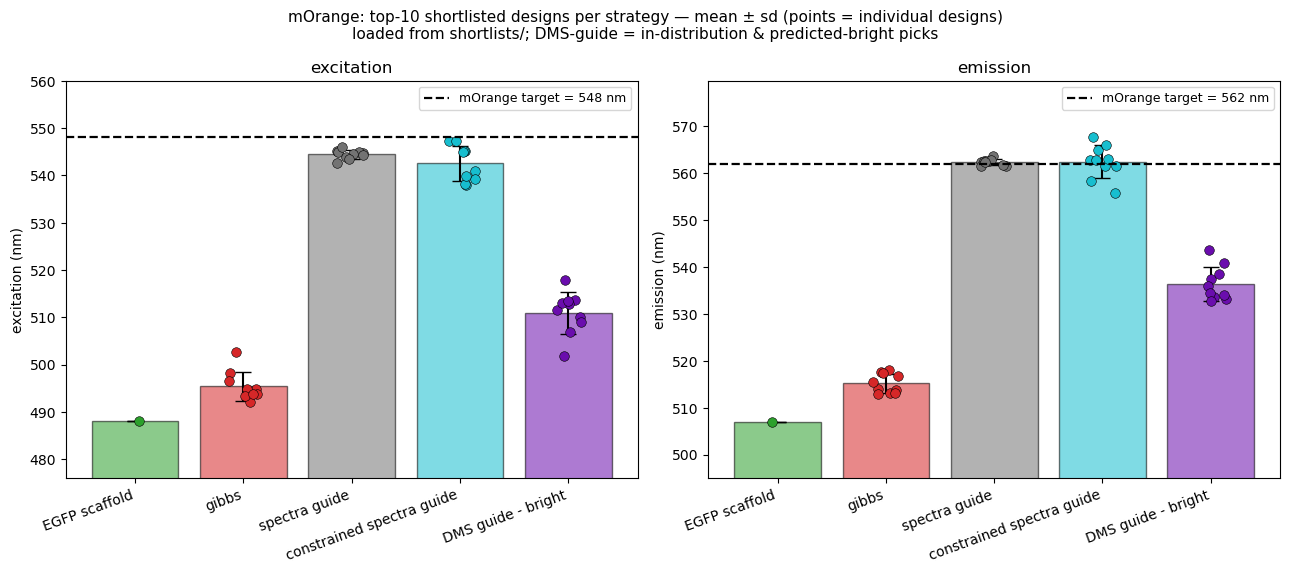

In [8]:
plot_groups("mOrange")

## Design-strategy comparison — the new `guided +edit` vs the rest

A single bar chart placing every EGFP design strategy on the **two pairs they all share** — **EBFP**
(large blue shift, ~99% seq id) and **mOrange** (red shift, ~30% seq id). All use the same surrogate
metric `peak_err = ½(|Δex| + |Δem|)` and the same "**each trial's best round**" rule as the lollipops
above. Bars are the **mean over trials**; the black ▾ marks the single **best design**; the dashed red
line is the **scaffold's** starting error; the dotted line is 10 nm. Bar labels show the mean and the
per-strategy trial count `n` (strategies were run to different depths).

Strategies:
- **gibbs** — pure ESM-2 masked-LM sampling (target-free; reconstructed per-target).
- **guided-only** — surrogate peaks-only steering.
- **guided +edit λ=10** — *new*: peaks steering **plus** the `lam_edit=10` edit penalty toward the scaffold (no brightness term).
- **brightness λ=40 / λ=60 +edit** — peaks + classifier-brightness + edit penalty.

The `guided +edit λ=10` run isolates the edit penalty on top of plain guided steering: it stays
on-target (best 0.1 nm EBFP, 0.8 nm mOrange — matching or beating guided-only) while, by construction,
pulling designs toward fewer mutations from the bright EGFP parent.

The printed table also reports **% predicted-bright** — the fraction of each strategy's unique
round≥1 designs whose full sequence scores `cnn-max-d2` brightness logit > 0 (one oracle applied
uniformly). This shows how often a strategy *actually produces* bright candidates: without a
brightness term the rate is ≈0% (even `guided +edit`, i.e. fewer mutations alone), whereas the
brightness-steered runs are far higher (and rise with `lam_bright`).

saved figures/campaign_strategy_comparison.png

% predicted-bright (cnn-max-d2 logit > 0) over unique round≥1 designs:
pair                   EGFP → EBFP  EGFP → mOrange
strategy                                          
brightness λ=60 +edit         80.0            34.0
gibbs                          0.0             0.0
guided +edit λ=10              0.0             0.0
guided-only                    0.0             0.0


,strategy,pair,mean_design,best_design,n_trials,scaffold_err,n_designs,pct_bright
0,gibbs,EGFP → EBFP,57.0,38.6,96,88.4,288,0.0
1,gibbs,EGFP → mOrange,63.8,44.7,96,56.6,288,0.0
2,guided-only,EGFP → EBFP,2.7,0.0,48,88.3,144,0.0
3,guided-only,EGFP → mOrange,15.7,1.7,96,56.7,288,0.0
4,guided +edit λ=10,EGFP → EBFP,1.9,0.1,48,88.3,144,0.0
5,guided +edit λ=10,EGFP → mOrange,20.5,0.8,96,56.7,288,0.0
6,brightness λ=60 +edit,EGFP → EBFP,30.5,6.4,96,88.3,284,79.9
7,brightness λ=60 +edit,EGFP → mOrange,39.1,17.4,96,56.7,287,34.1


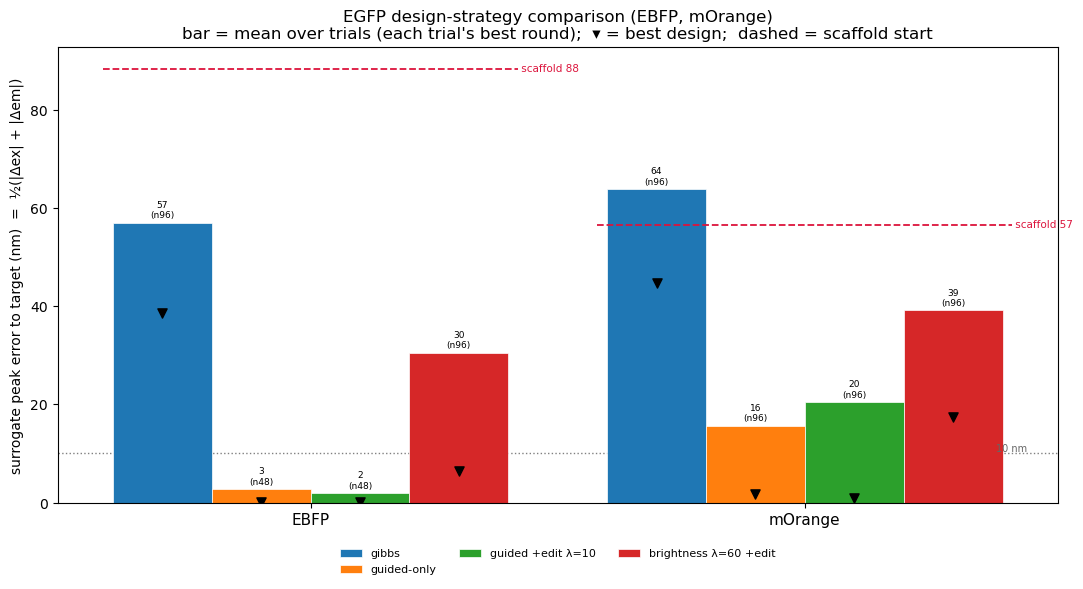

In [9]:
# ---- Strategy comparison bar chart (adds the new guided +edit constraint) --------------------
# Compares every EGFP design strategy on the two pairs they all share (EBFP, mOrange), using the same
# surrogate metric + "each trial's best round" rule as the per-pair lollipops above. Reuses df,
# dfg, DESIGNS, FIGDIR, load_designs, best_per_trial from the cells above.
CAMP = DESIGNS.parent.parent


def _load_if(dirpath):
    dirpath = Path(dirpath)
    return load_designs(dirpath) if glob.glob(str(dirpath / "design_*.csv")) else None


PAIRS_CMP = ["EGFP \u2192 EBFP", "EGFP \u2192 mOrange"]
STRAT_SETS = [
    ("gibbs",                      dfg),   # target-free, reconstructed per-target above
    ("guided-only",                df),    # surrogate peaks-only
    ("guided +edit \u03bb=10",     _load_if(CAMP / "guided-design-constraint" / "designs_lam-edit10")),
    ("brightness \u03bb=60 +edit", _load_if(CAMP / "brightness-guided" / "guided_design" / "designs_lam-bright60_lam-edit10")),
]
STRAT_SETS = [(n, d) for n, d in STRAT_SETS if d is not None]

recs = []
for name, d in STRAT_SETS:
    bt = best_per_trial(d)
    for p in PAIRS_CMP:
        b = bt.loc[bt["pair"] == p, "peak_err"]
        if b.empty:
            continue
        sc = d.loc[(d["pair"] == p) & (d["round"] == 0), "peak_err"].iloc[0]
        # % predicted-bright: score every unique design's FULL sequence with the same cnn-max-d2
        # brightness classifier (logit > 0 = bright), reusing _score_bright from the top-5 cell. This
        # applies ONE brightness oracle uniformly, so gibbs/guided (no pred_bright column) are scored
        # the same way as the brightness-guided runs.
        pool = d[(d["pair"] == p) & (d["round"] >= 1)].drop_duplicates("designed_seq")
        blog = _score_bright(pool["designed_seq"].tolist())
        pct_bright = 100.0 * float(np.mean(blog > 0)) if len(blog) else float("nan")
        recs.append(dict(strategy=name, pair=p, mean_design=b.mean(), best_design=b.min(),
                         n_trials=int(b.size), scaffold_err=sc,
                         n_designs=int(len(pool)), pct_bright=pct_bright))
cmp_df = pd.DataFrame(recs)

strat_order = [n for n, _ in STRAT_SETS]
cmap = plt.get_cmap("tab10")
colors = {n: cmap(i) for i, n in enumerate(strat_order)}

x = np.arange(len(PAIRS_CMP))
w = 0.8 / len(strat_order)
fig, ax = plt.subplots(figsize=(11, 6))
for i, name in enumerate(strat_order):
    sub = cmp_df[cmp_df["strategy"] == name].set_index("pair").reindex(PAIRS_CMP)
    xi = x - 0.4 + w * (i + 0.5)
    ax.bar(xi, sub["mean_design"], width=w, color=colors[name], edgecolor="white",
           linewidth=0.5, zorder=2, label=name)
    ax.scatter(xi, sub["best_design"], marker="v", s=44, color="black", zorder=4)
    for xv, mv, nt in zip(xi, sub["mean_design"], sub["n_trials"]):
        if np.isfinite(mv):
            ax.text(xv, mv + 0.6, f"{mv:.0f}\n(n{nt})", ha="center", va="bottom", fontsize=6.5)

for xc, p in zip(x, PAIRS_CMP):
    sc = cmp_df.loc[cmp_df["pair"] == p, "scaffold_err"].iloc[0]
    ax.hlines(sc, xc - 0.42, xc + 0.42, color="crimson", ls="--", lw=1.3, zorder=3)
    ax.text(xc + 0.42, sc, f" scaffold {sc:.0f}", va="center", fontsize=7.5, color="crimson")
ax.axhline(10, ls=":", color="0.5", lw=1, zorder=1)
ax.text(x[-1] + 0.45, 10, "10 nm", va="bottom", ha="right", fontsize=7, color="0.4")

ax.set_xticks(x)
ax.set_xticklabels([p.split("\u2192")[1].strip() for p in PAIRS_CMP], fontsize=11)
ax.set_ylabel("surrogate peak error to target (nm)  =  \u00bd(|\u0394ex| + |\u0394em|)")
ax.set_title("EGFP design-strategy comparison (EBFP, mOrange)\n"
             "bar = mean over trials (each trial's best round);  \u25be = best design;  dashed = scaffold start")
ax.legend(fontsize=8, ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08))
fig.tight_layout()
fig.savefig(FIGDIR / "campaign_strategy_comparison.png", dpi=130, bbox_inches="tight")
print("saved", FIGDIR / "campaign_strategy_comparison.png")
print("\n% predicted-bright (cnn-max-d2 logit > 0) over unique round\u22651 designs:")
print(cmp_df.pivot(index="strategy", columns="pair", values="pct_bright").round(0).to_string())
cmp_df.round(1)